完成作业后，请运行所有单元格，并将 notebook 保存为 PDF 用于 Gradescope 提交（可按 Ctrl-P 或 Cmd-P 打印）。请确保图片不要被分页截断；如有必要，请在打印 PDF 前插入文本单元格来调整分页。


马楷恒 231880174

---




# **16385 作业 3：三维重建**

# 问题 1：理论（20 分）


## 1.1 [10 分]
请参见 PDF 中的题目。




$$ \begin{array}{l}
\because \mathbf{x}^{\mathrm{T}}\mathbf{Fx}=0 \\
\therefore \begin{bmatrix} 0 & 0 & 1 \end{bmatrix}\begin{bmatrix}
f_{11} & f_{12} & f_{13} \\ f_{21} & f_{22} & f_{23} \\ f_{31} & f_{32} & f_{33}
\end{bmatrix}\begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}=0 \\
\therefore f_{33}=0
\end{array} $$

## 1.2 [10 分]
请参见 PDF 中的题目。


$$ \begin{align}
&\left\{\begin{array}{l} x_{i}=R_{i}X+t_{i} \\ x_{i+1}=R_{t+1}X+t_{i+1} \\ x_{i+1}=R_{\text{rel}}(x_{i}-t_{\text{rel}}) \end{array}\right. \\
\therefore\; &R_{i+1}X+t_{i+1}=R_{\text{rel}}R_{i}X+R_{\text{rel}}(t_{i}-t_{\text{rel}}) \\
\therefore\; &\left\{\begin{array}{l} R_{i+1}=R_{\text{rel}}R_{i} \\ t_{i+1}=R_{\text{rel}}(t_{i}-t_{\text{rel}}) \end{array}\right. \\
\therefore\; &\left\{\begin{array}{l} R_{\text{rel}}=R_{i+1}R_{i}^{\mathrm{T}} \\ t_{\text{rel}}=t_{i}-R_{i}R_{i+1}^{\mathrm{T}}t_{i+1} \end{array}\right. \\
& E=R_{\text{rel}}[t_{\text{rel}\times}],F=K^{\mathrm{-T}}EK^{-1}=K^{\mathrm{-T}}R_{\text{rel}}[t_{\text{rel}\times}]K^{-1}
\end{align} $$

# **编程部分**


## **初始化**

运行下面的代码，它会导入本作业需要的模块，并定义之后实现中可能用到的辅助函数。


In [1]:
import os
import numpy as np
import scipy
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import cv2


def calc_epi_error(pts1_homo, pts2_homo, F):
    r"""
    辅助函数：计算对应点到估计对极线之间的平方距离之和。

    pts1_homo \dot F.T \dot pts2_homo = 0

    :param pts1_homo: 形状为 (num_points, 3)，齐次坐标，未归一化。
    :param pts2_homo: 与 pts1_homo 规格相同。
    :param F: 基础矩阵
    """

    line1s = pts1_homo.dot(F.T)
    dist1 = np.square(np.divide(np.sum(np.multiply(
        line1s, pts2_homo), axis=1), np.linalg.norm(line1s[:, :2], axis=1)))

    line2s = pts2_homo.dot(F)
    dist2 = np.square(np.divide(np.sum(np.multiply(
        line2s, pts1_homo), axis=1), np.linalg.norm(line2s[:, :2], axis=1)))

    ress = (dist1 + dist2).flatten()
    return ress


def toHomogenous(pts):
    """
    在点集最后添加一列 1，将二维点转换为齐次坐标点。

    :params pts: 形状为 (num_points, 2)。
    """
    return np.vstack([pts[:,0],pts[:,1],np.ones(pts.shape[0])]).T.copy()


def _epipoles(E):
    """
    从本质矩阵/基础矩阵中计算极点。

    :params E: 本质矩阵或基础矩阵。
    """
    U, S, V = np.linalg.svd(E)
    e1 = V[-1, :]
    U, S, V = np.linalg.svd(E.T)
    e2 = V[-1, :]
    return e1, e2


def displayEpipolarF(I1, I2, F, points):
    """
    可用于检查基础矩阵 F 的绘图辅助函数。
    在第一张图像中给定若干点，函数会在第二张图像中画出对应的对极线。
    """
    e1, e2 = _epipoles(F)

    sy, sx, _ = I2.shape

    f, [ax1, ax2] = plt.subplots(1, 2, figsize=(12, 9))
    ax1.imshow(I1)
    ax1.set_title('Selected Points：')
    ax2.imshow(I2)
    ax2.set_title('Verify that the corresponding point \n is on the epipolar line in this image')

    plt.sca(ax1)

    colors = ['r','g','b','y','m','k']
    for i, out in enumerate(points):
      x, y = out #[0]

      xc = x
      yc = y
      v = np.array([xc, yc, 1])
      l = F.dot(v)
      s = np.sqrt(l[0]**2+l[1]**2)

      if s==0:
          print('displayEpipolar 中出现零线向量')

      l = l/s

      if l[0] != 0:
          ye = sy-1
          ys = 0
          xe = -(l[1] * ye + l[2])/l[0]
          xs = -(l[1] * ys + l[2])/l[0]
      else:
          xe = sx-1
          xs = 0
          ye = -(l[0] * xe + l[2])/l[1]
          ys = -(l[0] * xs + l[2])/l[1]

      # plt.plot(x,y, '*', 'MarkerSize', 6, 'LineWidth', 2);
      ax1.plot(x, y, '*', markersize=6, linewidth=2, color=colors[i%len(colors)])
      ax2.plot([xs, xe], [ys, ye], linewidth=2, color=colors[i%len(colors)])
    plt.draw()


def _singularize(F):
    U, S, V = np.linalg.svd(F)
    S[-1] = 0
    F = U.dot(np.diag(S).dot(V))
    return F

def _objective_F(f, pts1, pts2):
    F = _singularize(f.reshape([3, 3]))
    num_points = pts1.shape[0]
    # hpts1 = np.concatenate([pts1, np.ones([num_points, 1])], axis=1)
    # hpts2 = np.concatenate([pts2, np.ones([num_points, 1])], axis=1)
    Fp1 = F.dot(pts1.T)
    FTp2 = F.T.dot(pts2.T)

    r = 0
    for fp1, fp2, hp2 in zip(Fp1.T, FTp2.T, pts2):
        r += (hp2.dot(fp1))**2 * (1/(fp1[0]**2 + fp1[1]**2) + 1/(fp2[0]**2 + fp2[1]**2))
    return r

def refineF(F, pts1, pts2):
    f = scipy.optimize.fmin_powell(
        lambda x: _objective_F(x, pts1, pts2), F.reshape([-1]),
        maxiter=100000,
        maxfun=10000,
        disp=False
    )
    return _singularize(f.reshape([3, 3]))


# 用于 4.2 对极对应搜索的可视化调试函数
def epipolarMatchGUI(I1, I2, F, points, epipolarCorrespondence):
    e1, e2 = _epipoles(F)

    sy, sx, _ = I2.shape

    f, [ax1, ax2] = plt.subplots(1, 2, figsize=(12, 9))
    ax1.imshow(I1)
    ax1.set_title('你选择的点：')
    ax2.imshow(I2)
    ax2.set_title('Verify that the corresponding point \n is on the epipolar line in this image \nand that the corresponding point matches')

    plt.sca(ax1)

    colors = ['r','g','b','y','m','k']

    for i, out in enumerate(points):
      x, y = out

      xc = int(x)
      yc = int(y)
      v = np.array([xc, yc, 1])
      l = F.dot(v)
      s = np.sqrt(l[0]**2+l[1]**2)

      if s==0:
          print('displayEpipolar 中出现零线向量')

      l = l/s

      if l[0] != 0:
          ye = sy-1
          ys = 0
          xe = -(l[1] * ye + l[2])/l[0]
          xs = -(l[1] * ys + l[2])/l[0]
      else:
          xe = sx-1
          xs = 0
          ye = -(l[0] * xe + l[2])/l[1]
          ys = -(l[0] * xs + l[2])/l[1]

      ax1.plot(x, y, '*', markersize=6, linewidth=2, color=colors[i%len(colors)])
      ax2.plot([xs, xe], [ys, ye], linewidth=2, color=colors[i%len(colors)])

      # 画出由 epipolarCorrespondence 找到的匹配点
      x2, y2 = epipolarCorrespondence(I1, I2, F, xc, yc)
      ax2.plot(x2, y2, 'ro', markersize=8, linewidth=2)
      plt.draw()



## **准备数据**
本节会下载测试用的图像视角、相机内参和点对应关系，这些数据将用于测试你的实现。


In [2]:
if not os.path.exists('data'):
  !wget https://www.andrew.cmu.edu/user/eweng/data.zip -O data.zip
  !unzip -qq "data.zip"
  print("已下载并解压数据")

# 问题 2：使用八点算法估计基础矩阵 [15 分]


在本部分中，请实现课堂中学到的八点算法，用两张图像中的对应点估计基础矩阵。


In [3]:
def eightpoint(pts1, pts2, M):
  '''
  Q2：八点算法。
  输入：  pts1，Nx2 矩阵
          pts2，Nx2 矩阵
          M，一个标量参数，通常取 max(imwidth, imheight)
  输出： F，基础矩阵

  提示：
  (1) 使用矩阵 T 对输入 pts1 和 pts2 进行归一化。
  (2) 建立八点算法对应的线性方程。
  (3) 使用 SVD 求最小二乘解。
  (4) 使用上方提供的 `_singularize` 函数强制满足奇异性条件。
  (5) 使用上方提供的 `refineF` 函数优化计算得到的基础矩阵。
      注意：这里应使用归一化后的点，而不是原始点。
  (6) 将基础矩阵反缩放，并用右下角元素进行归一化。
  '''


  F = None
  N = pts1.shape[0]

  # ===== 在这里填写你的代码！ =====
  T = np.diag([1 / M, 1 / M, 1])
  pts1 = toHomogenous(pts1)
  pts2 = toHomogenous(pts2)
  pts1 = pts1 @ T
  pts2 = pts2 @ T
  A = np.stack([
      pts1[:, 0] * pts2[:, 0],
      pts1[:, 0] * pts2[:, 1],
      pts1[:, 0],
      pts1[:, 1] * pts2[:, 0],
      pts1[:, 1] * pts2[:, 1],
      pts1[:, 1],
      pts2[:, 0],
      pts2[:, 1],
      np.ones(N),
  ], axis=1)
  U, S, V = np.linalg.svd(A)
  F = V[-1, :].T
  F = _singularize(F.reshape(3, 3))
  F = refineF(F, pts1, pts2)
  F = T.T @ F @ T
  F = F / F[2, 2]

  # ===== 代码结束 =====

  return F

运行以下代码测试八点算法实现。你的代码应通过最后的所有 assert 检查。


In [4]:
correspondence = np.load('data/some_corresp.npz') # 加载对应点
intrinsics = np.load('data/intrinsics.npz') # 加载相机内参
K1, K2 = intrinsics['K1'], intrinsics['K2']
pts1, pts2 = correspondence['pts1'], correspondence['pts2']
im1 = plt.imread('data/im1.png')
im2 = plt.imread('data/im2.png')

F = eightpoint(pts1, pts2, M=np.max([*im1.shape, *im2.shape]))
print(f'恢复得到的 F:\n{F.round(4)}')

# 简单测试：检查你的实现
pts1_homogenous, pts2_homogenous = toHomogenous(pts1), toHomogenous(pts2)

assert F.shape == (3, 3), "F 的形状错误"
assert F[2, 2] == 1, "F_33 != 1"
assert np.linalg.matrix_rank(F) == 2, "F 应为秩 2"
assert np.mean(calc_epi_error(pts1_homogenous, pts2_homogenous, F)) < 1, "F 的误差过大，结果不够准确"

恢复得到的 F:
[[-0.      0.     -0.2811]
 [ 0.      0.     -0.0099]
 [ 0.2713  0.0046  1.    ]]


下面的工具可以帮助你调试。你可以在 im1 中指定一个点，并根据求得的 F 查看 im2 中对应的对极线。提交中请包含下面生成的调试图，图中至少展示 5 组对极点-线对应关系，以说明 F 的计算正确。




C:\Users\27344\AppData\Local\Temp\ipykernel_15448\2450087517.py:101: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.draw()
C:\Users\27344\.conda\envs\AI\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


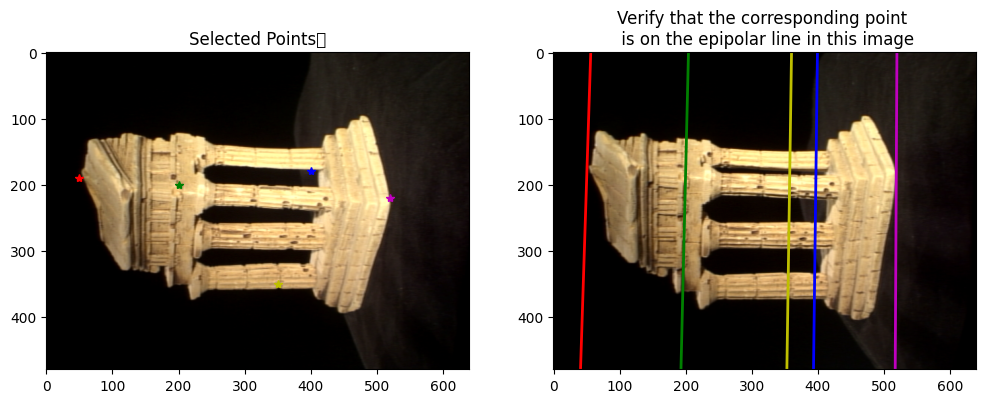

In [5]:
# im1 中需要验证其在 im2 中对应对极线的点
point = [(50,190),(200, 200), (400,180), (350,350), (520, 220)]
# 你可以修改这些点，以验证不同的点对应关系
displayEpipolarF(im1, im2, F, point)

# 问题 3：度量重建（40 分）


## 3.1 本质矩阵 [10 分]


In [ ]:

def essentialMatrix(F, K1, K2):
  '''
  Q3.1：计算本质矩阵 E。
    输入：  F，基础矩阵
            K1，相机 1 的内参矩阵
            K2，相机 2 的内参矩阵
    输出： E，本质矩阵
  '''

  # ----- TODO -----
  ### BEGIN SOLUTION

  ### END SOLUTION
  return E

运行以下代码检查你的实现。


In [ ]:
correspondence = np.load('data/some_corresp.npz') # 加载对应点
intrinsics = np.load('data/intrinsics.npz') # 加载相机内参
K1, K2 = intrinsics['K1'], intrinsics['K2']
pts1, pts2 = correspondence['pts1'], correspondence['pts2']
im1 = plt.imread('data/im1.png')
im2 = plt.imread('data/im2.png')

F = eightpoint(pts1, pts2, M=np.max([*im1.shape, *im2.shape]))
E = essentialMatrix(F, K1, K2)
print(f'恢复得到的 E:\n{E.round(4)}')

# 简单测试：检查你的实现
assert(E[2, 2] == 1)
assert(np.linalg.matrix_rank(E) == 2)

# 3.2 三角化 [15 分]



In [ ]:
def triangulate(C1, pts1, C2, pts2):
  '''
  Q3.2：将图像中的一组二维坐标三角化为一组三维点。
  输入：  C1，3x4 相机矩阵
          pts1，Nx2 矩阵，每行是图像 1 中的二维坐标
          C2，3x4 相机矩阵
          pts2，Nx2 矩阵，每行是图像 2 中的二维坐标
  输出： P，Nx3 矩阵，每行是对应的三维点
          err，重投影误差。

  提示：
  (1) 对每个输入点，根据 pts1、pts2、C1、C2 构造矩阵 A。
  (2) Solve for the least square solution using np.linalg.svd
  (3) 使用计算得到的三维点以及 C1、C2 计算重投影误差。
      注意需要从齐次坐标转换回非齐次坐标。
  (4) 记录三维点与投影误差，然后继续处理下一个点。
  (5) 你不必严格遵循以上步骤。
  '''

  # ----- TODO -----
  ### BEGIN SOLUTION

  ### END SOLUTION

  return P, err

## 3.3 寻找 M2 [15 分]


In [ ]:
def camera2(E):
  """辅助函数：根据本质矩阵 E 找到 4 个可能的 M2 矩阵。"""
  U,S,V = np.linalg.svd(E)
  m = S[:2].mean()
  E = U.dot(np.array([[m,0,0], [0,m,0], [0,0,0]])).dot(V)
  U,S,V = np.linalg.svd(E)
  W = np.array([[0,-1,0], [1,0,0], [0,0,1]])

  if np.linalg.det(U.dot(W).dot(V))<0:
      W = -W

  M2s = np.zeros([3,4,4])
  M2s[:,:,0] = np.concatenate([U.dot(W).dot(V), U[:,2].reshape([-1, 1])/abs(U[:,2]).max()], axis=1)
  M2s[:,:,1] = np.concatenate([U.dot(W).dot(V), -U[:,2].reshape([-1, 1])/abs(U[:,2]).max()], axis=1)
  M2s[:,:,2] = np.concatenate([U.dot(W.T).dot(V), U[:,2].reshape([-1, 1])/abs(U[:,2]).max()], axis=1)
  M2s[:,:,3] = np.concatenate([U.dot(W.T).dot(V), -U[:,2].reshape([-1, 1])/abs(U[:,2]).max()], axis=1)
  return M2s


def findM2(F, pts1, pts2, intrinsics):
    '''
    Q3.3：根据对应点寻找第二个相机的投影矩阵。
        输入：  F, 预先计算好的基础矩阵
                pts1，Nx2 矩阵，每行是图像 1 中的二维坐标
                pts2，Nx2 矩阵，每行是图像 2 中的二维坐标
                intrinsics, 相机内参字典，从 .npz 文件中加载
                filename，用于保存结果的文件名（本版本无需使用）
        输出： [M2, C2, P] 计算得到的 M2（3x4）相机外参矩阵、C2（3x4）= K2 * M2，以及三维点 P（Nx3）

    ***
    提示：
    (1) 遍历 `M2s`，使用 triangulate 计算三维点和投影误差。需要记录哪一个解使点位于相机前方（z 为正）。
    (2) 查看 camera2 函数，理解如何从 `M2s` 中正确取出候选 M2。

    '''

    K1, K2 = intrinsics['K1'], intrinsics['K2']

    # ----- TODO -----
    ### BEGIN SOLUTION

    ### END SOLUTION

    return M2, C2, P

运行以下代码检查 triangulate 和 findM2 的实现。


In [ ]:
correspondence = np.load('data/some_corresp.npz') # 加载对应点
intrinsics = np.load('data/intrinsics.npz') # 加载相机内参
K1, K2 = intrinsics['K1'], intrinsics['K2']
pts1, pts2 = correspondence['pts1'], correspondence['pts2']
im1 = plt.imread('data/im1.png')
im2 = plt.imread('data/im2.png')

F = eightpoint(pts1, pts2, M=np.max([*im1.shape, *im2.shape]))

M2, C2, P = findM2(F, pts1, pts2, intrinsics)

# 简单测试：检查你的实现
M1 = np.hstack((np.identity(3), np.zeros(3)[:,np.newaxis]))
C1 = K1.dot(M1)
C2 = K2.dot(M2)
P_test, err = triangulate(C1, pts1, C2, pts2)
assert(err < 500)

# 问题 4：三维可视化（25 分）


In [ ]:
def epipolarCorrespondence(im1, im2, F, x1, y1):
  '''
  Q4.1：temple 图像三维可视化中的对极对应搜索。
  输入：  im1，第一张图像
          im2，第二张图像
          F，基础矩阵
          x1，im1 中某个像素的 x 坐标
          y1，im1 中某个像素的 y 坐标
  输出： x2，im2 中对应像素的 x 坐标
          y2，im2 中对应像素的 y 坐标

  提示：
  (1) 给定输入 [x1, y1]，使用基础矩阵在图像 2 中恢复对应的对极线。
  (2) 沿该对极线搜索，比较附近像素强度（可以自行定义搜索窗口），找到最佳匹配。
  (3) 可以使用高斯权重来加权像素相似度。

  '''
  # ----- TODO -----
  # 在这里填写你的代码

  # 代码结束
  return x2, y2

运行以下代码检查你的实现。


In [ ]:
correspondence = np.load('data/some_corresp.npz') # 加载对应点
intrinsics = np.load('data/intrinsics.npz') # 加载相机内参
K1, K2 = intrinsics['K1'], intrinsics['K2']
pts1, pts2 = correspondence['pts1'], correspondence['pts2']
im1 = plt.imread('data/im1.png')
im2 = plt.imread('data/im2.png')

F = eightpoint(pts1, pts2, M=np.max([*im1.shape, *im2.shape]))

# 简单测试：检查你的实现
x2, y2 = epipolarCorrespondence(im1, im2, F, 119, 217)
assert(np.linalg.norm(np.array([x2, y2]) - np.array([118, 181])) < 10)

使用下面的工具调试你的代码。


In [ ]:
# im1 中需要验证其在 im2 中对应对极线和匹配点的点
points = [(50,190), (200, 200), (400,180), (350,350), (520, 220)]
# 你可以修改这些点，以验证不同的点对应关系
epipolarMatchGUI(im1, im2, F, points, epipolarCorrespondence)

## 4.2 Temple 三维可视化 [10 分]


In [ ]:
def compute3D_pts(temple_pts1, intrinsics, F, im1, im2):
  '''
  Q4.2：基于对极对应和三角化，寻找给定点的三维位置。
  输入：  temple_pts1，从 im1 中选出的点
          intrinsics，用于调用 epipolarCorrespondence 的相机内参字典
          F，基础矩阵
          im1，第一张图像
          im2，第二张图像
  输出： P，Nx3 矩阵，恢复出的三维点

  提示：
  (1) 使用 epipolarCorrespondence 为 [x1, y1] 找到对应点 [x2, y2]。
  (2) 得到一组对应点 [x1, y1] 与 [x2, y2] 后，可以计算 M2 矩阵，
      并使用 triangulate 求出三维点。
  (3) 使用 findM2 函数求三维点 P（不要重新计算基础矩阵）。
  (4) 作为参考，我们的解在这些三维点上的最佳误差约为 2200。
  '''
  # ----- TODO -----
  # 在这里填写你的代码

  return P
  # 代码结束


下面将所有部分整合起来。
提供的 starter code 会加载 `data/templeCoords.npz` 中的 temple 数据，其中包含从 im1 中手工选出的 288 个点，变量名为 x1 和 y1。
接着，调用你刚实现的函数和其他必要函数，从二维点对应关系得到三维点。最后，使用 matplotlib 或 plotly 的三维散点图可视化三维重建结果。




In [ ]:
temple_coords = np.load('data/templeCoords.npz') # 加载 temple 坐标
correspondence = np.load('data/some_corresp.npz') # 加载对应点
intrinsics = np.load('data/intrinsics.npz') # 加载相机内参
K1, K2 = intrinsics['K1'], intrinsics['K2']
pts1, pts2 = correspondence['pts1'], correspondence['pts2']
im1 = plt.imread('data/im1.png')
im2 = plt.imread('data/im2.png')

# ----- TODO -----
# 调用 eightpoint 得到 F 矩阵
# 调用 compute3D_pts 得到三维点，并使用 matplotlib scatter 进行可视化
# 提示：你可以使用下面的方法改变 matplotlib 3D 坐标轴视角：
# `ax.view_init(azim, elev)` where azim is the rotation around the vertical z
# axis, and elev is the angle of elevation from the x-y plane

temple_pts1 = np.hstack([temple_coords['x1'], temple_coords['y1']])

# 在这里填写你的代码

# 代码结束

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(P[:, 0], P[:, 1], P[:, 2], s=10, c='c', depthshade=True)
plt.draw()

# 再展示一个不同视角
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(P[:, 0], P[:, 1], P[:, 2], s=10, c='c', depthshade=True)
ax.view_init(30, 0)
plt.draw()
